# Evaluate similarity suggestions

In [1]:
%load_ext autoreload

In [2]:
import os
import pickle
from os.path import join
from IPython.display import display, Markdown, display_html

import scanpy as sc
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt

In [3]:
%autoreload
from datasim.dataset_ot import DatasetMapping

## Load and preprocess data

In [4]:
DATA_PATH = "/vol/data/dataset-similarity/preprocessed"
MODEL_DIR = "/vol/data/dataset-similarity/models/similarityOT"
CACHE_DIR = "/vol/data/dataset-similarity/cache"
FIG_DIR = "/vol/data/dataset-similarity/figures"


QUERY_DATASET = "7d7cabfd-1d1f-40af-96b7-26a0825a306d"
REF_DATASET = "ced320a1-29f3-47c1-a735-513c7084d508_CAP_NKT_CD3E"
# REF_DATASET = "ced320a1-29f3-47c1-a735-513c7084d508_CAP"
N_TOP_GENES = 750

In [5]:
cache_file = join(
    CACHE_DIR, 
    "+".join([QUERY_DATASET, REF_DATASET, f"{N_TOP_GENES}HVGs"]) + ".pickle"
)
with open(cache_file, "rb") as f:
    adata_query, adata_ref = pickle.load(f)

In [6]:
adata_query

AnnData object with n_obs × n_vars = 600929 × 750
    obs: 'assay', 'cell_type', 'development_stage', 'disease', 'donor_id', 'is_primary_data', 'sex', 'suspension_type', 'tissue', 'batch', 'ct1', 'ct2', 'ct3', 'cell_type_author', 'sample_id'
    var: 'feature_id'
    uns: 'de_res_ova', 'de_res_ava'
    obsm: 'X_scTab'

In [7]:
adata_ref

AnnData object with n_obs × n_vars = 1265624 × 750
    obs: 'assay', 'cell_type', 'development_stage', 'disease', 'donor_id', 'is_primary_data', 'sex', 'suspension_type', 'tissue', 'sample_uuid', 'author_cell_type', 'cell_type_author', 'sample_id'
    var: 'feature_id'
    uns: 'de_res_ova', 'de_res_ava'
    obsm: 'X_scTab'

In [8]:
MODEL_VERSION = (
    f"{QUERY_DATASET}+{REF_DATASET}"
    "+n_genes_ova=10"
    "+n_genes_ava=3"
    "+tau=1.0"
    "+epsilon=0.05"
    "+overlap_threshold_ava=0.3"
    "+overlap_n_genes_ava=10"
)

mapping = pd.read_parquet(join(MODEL_DIR, MODEL_VERSION, "mapping_mean.parquet"))
distance = pd.read_parquet(join(MODEL_DIR, MODEL_VERSION, "distance.parquet"))

In [9]:
def extract_ontology_mapping(adata):
    return (
        adata.obs[["cell_type_author", "cell_type"]]
        .drop_duplicates()
        .set_index("cell_type_author")["cell_type"]
        .to_dict()
    )


ontology_mapping_query = extract_ontology_mapping(adata_query)
ontology_mapping_ref = extract_ontology_mapping(adata_ref)

## Select most similar clusters

In [10]:
top_n_labels = DatasetMapping.select_most_similar_clusters(
    mapping, 
    distance, 
    threshold_mapping=0.25,
    threshold_distance=1.,
    n_top=None
)
top_n_labels

{'B_Mem': ['memory_B_IGHMhi'],
 'B_Mem_Prolif': ['memory_B_IGHMlo', 'memory_B'],
 'B_Naive': ['naive_B'],
 'B_Preplasma': ['atypical_B'],
 'NKT': ['NKT'],
 'NK_CD16+': ['CD16+_NK', 'NK'],
 'NK_CD56++': ['CD56+_NK'],
 'NK_Prolif': [],
 'PB': ['Plasma_Cell'],
 'PB_Prolif': [],
 'Progen_CLP': [],
 'Progen_CMP': [],
 'Progen_MEP': [],
 'Progen_MPP': ['CD34_HSPC'],
 'T4_Mem': ['CD4+_T_cm', 'CD4+_T'],
 'T4_Mem_Prolif': ['dnT'],
 'T4_Naive': ['CD4+_T_naive', 'CD4+_T'],
 'T4_Treg': ['Treg'],
 'T8_MAIT': ['MAIT'],
 'T8_Mem': ['CD8+_T_unknown', 'CD8+_T_GZMBhi', 'CD4+_T_cyt'],
 'T8_Mem_Prolif': ['CD8+_T_GZMKhi'],
 'T8_Naive': ['CD8+_T_naive'],
 'T_NK_Prolif': [],
 'Tgd_1': ['CD8+_T_GZMBhi', 'CD4+_T_cyt', 'CD8+_T_unknown'],
 'Tgd_2': ['gdT_GZMKhi', 'gdT_GZMBhi'],
 'cDC_1': ['cDC1'],
 'cDC_2': ['cDC2'],
 'cM': ['CD14+_Monocyte', 'Myeloid'],
 'ncM': ['CD16+_Monocyte'],
 'pDC': ['pDC']}

#### Author provided cluster labels

In [11]:
summaries = []
for i, (k, v) in enumerate(top_n_labels.items()):
    summaries.append(f"*{i+1}*: **{k}**: {v} <br>")

display(Markdown("".join(summaries)))

*1*: **B_Mem**: ['memory_B_IGHMhi'] <br>*2*: **B_Mem_Prolif**: ['memory_B_IGHMlo', 'memory_B'] <br>*3*: **B_Naive**: ['naive_B'] <br>*4*: **B_Preplasma**: ['atypical_B'] <br>*5*: **NKT**: ['NKT'] <br>*6*: **NK_CD16+**: ['CD16+_NK', 'NK'] <br>*7*: **NK_CD56++**: ['CD56+_NK'] <br>*8*: **NK_Prolif**: [] <br>*9*: **PB**: ['Plasma_Cell'] <br>*10*: **PB_Prolif**: [] <br>*11*: **Progen_CLP**: [] <br>*12*: **Progen_CMP**: [] <br>*13*: **Progen_MEP**: [] <br>*14*: **Progen_MPP**: ['CD34_HSPC'] <br>*15*: **T4_Mem**: ['CD4+_T_cm', 'CD4+_T'] <br>*16*: **T4_Mem_Prolif**: ['dnT'] <br>*17*: **T4_Naive**: ['CD4+_T_naive', 'CD4+_T'] <br>*18*: **T4_Treg**: ['Treg'] <br>*19*: **T8_MAIT**: ['MAIT'] <br>*20*: **T8_Mem**: ['CD8+_T_unknown', 'CD8+_T_GZMBhi', 'CD4+_T_cyt'] <br>*21*: **T8_Mem_Prolif**: ['CD8+_T_GZMKhi'] <br>*22*: **T8_Naive**: ['CD8+_T_naive'] <br>*23*: **T_NK_Prolif**: [] <br>*24*: **Tgd_1**: ['CD8+_T_GZMBhi', 'CD4+_T_cyt', 'CD8+_T_unknown'] <br>*25*: **Tgd_2**: ['gdT_GZMKhi', 'gdT_GZMBhi'] <br>*26*: **cDC_1**: ['cDC1'] <br>*27*: **cDC_2**: ['cDC2'] <br>*28*: **cM**: ['CD14+_Monocyte', 'Myeloid'] <br>*29*: **ncM**: ['CD16+_Monocyte'] <br>*30*: **pDC**: ['pDC'] <br>

#### Ontology mapped cluster labels

In [12]:
summaries = []
for i, (k, v) in enumerate(top_n_labels.items()):
    summaries.append(
        f"*{i+1}*: **{ontology_mapping_query[k]}**: {[ontology_mapping_ref[elem] for elem in v]} <br>"
    )

display(Markdown("".join(summaries)))

*1*: **B cell**: ['memory B cell'] <br>*2*: **B cell**: ['memory B cell', 'memory B cell'] <br>*3*: **B cell**: ['naive B cell'] <br>*4*: **B cell**: ['mature B cell'] <br>*5*: **natural killer cell**: ['CD16-negative, CD56-bright natural killer cell, human'] <br>*6*: **natural killer cell**: ['CD16-positive, CD56-dim natural killer cell, human', 'natural killer cell'] <br>*7*: **natural killer cell**: ['CD16-negative, CD56-bright natural killer cell, human'] <br>*8*: **natural killer cell**: [] <br>*9*: **plasmablast**: ['plasma cell'] <br>*10*: **plasmablast**: [] <br>*11*: **progenitor cell**: [] <br>*12*: **progenitor cell**: [] <br>*13*: **progenitor cell**: [] <br>*14*: **progenitor cell**: ['hematopoietic stem cell'] <br>*15*: **CD4-positive, alpha-beta T cell**: ['central memory CD4-positive, alpha-beta T cell', 'CD4-positive, alpha-beta T cell'] <br>*16*: **CD4-positive, alpha-beta T cell**: ['double negative T regulatory cell'] <br>*17*: **CD4-positive, alpha-beta T cell**: ['naive thymus-derived CD4-positive, alpha-beta T cell', 'CD4-positive, alpha-beta T cell'] <br>*18*: **CD4-positive, alpha-beta T cell**: ['regulatory T cell'] <br>*19*: **CD8-positive, alpha-beta T cell**: ['mucosal invariant T cell'] <br>*20*: **CD8-positive, alpha-beta T cell**: ['CD8-positive, alpha-beta T cell', 'CD8-positive, alpha-beta cytotoxic T cell', 'CD4-positive, alpha-beta cytotoxic T cell'] <br>*21*: **CD8-positive, alpha-beta T cell**: ['CD8-positive, alpha-beta memory T cell'] <br>*22*: **CD8-positive, alpha-beta T cell**: ['naive thymus-derived CD8-positive, alpha-beta T cell'] <br>*23*: **CD4-positive, alpha-beta T cell**: [] <br>*24*: **gamma-delta T cell**: ['CD8-positive, alpha-beta cytotoxic T cell', 'CD4-positive, alpha-beta cytotoxic T cell', 'CD8-positive, alpha-beta T cell'] <br>*25*: **gamma-delta T cell**: ['gamma-delta T cell', 'gamma-delta T cell'] <br>*26*: **conventional dendritic cell**: ['CD141-positive myeloid dendritic cell'] <br>*27*: **conventional dendritic cell**: ['CD1c-positive myeloid dendritic cell'] <br>*28*: **classical monocyte**: ['CD14-positive monocyte', 'myeloid cell'] <br>*29*: **non-classical monocyte**: ['CD14-low, CD16-positive monocyte'] <br>*30*: **plasmacytoid dendritic cell**: ['plasmacytoid dendritic cell'] <br>

## Evaluate cluster similarity

In [14]:
MARKER_GENE_EVIDENCE_REF = {
    "B_unknown": ["MS4A1", "CD79A"],
    "memory_B": ["MS4A1", "CD79A", "CD27", "TNFRSF13B"],
    "memory_B_IGHMhi": ["MS4A1", "CD79A", "CD27", "TNFRSF13B", "IGHM"],
    "memory_B_IGHMlo": ["MS4A1", "CD79A", "CD27", "TNFRSF13B"],
    "naive_B": ["MS4A1", "CD79A", "TCL1A", "IGHM", "IGHD"],
    "CD14+_Monocyte": ["CD68", "CD14", "CSF3R", "S100A12", "S100A8", "S100A9"],
    "CD16+_Monocyte": ["CD68", "FCGR3A", "CX3CR1", "CDKN1C", "CSF1R", "ITGAL"],
    "CD16+_NK": ["NKG7", "GNLY", "TYROBP", "KLRD1", "FCGR3A", "PRF1", "FGFBP2", "SPON2"],
    "CD34_HSPC": ["CD34"],
    "CD4+_T": ["CD3D", "CD3G", "CD4"],
    "CD4+_T_cm": ["CD3D", "CD3G", "CD4", "CCR7", "SELL", "LEF1", "ITGB1"],
    "CD4+_T_em": ["CD3D", "CD3G", "CD4", "ITGB1", "KLRB1", "CCL5", "GZMA", "GZMK"],
    "CD4+_T_cyt": ["CD3D", "CD3G", "CD4", "CCR7", "SELL", "LEF1", "TCF7", "IL7R", "BACH2"],
    "CD4+_T_naive": ["CD3D", "CD3G", "CD4", "CCR7", "SELL", "LEF1", "TCF7", "IL7R", "BACH2"],
    "CD56+_NK": ["NKG7", "GNLY", "TYROBP", "KLRD1", "NCAM1", "XCL1", "XCL2", "KLRC1"],
    "CD8+_T_GZMBhi": ["CD3D", "CD3G", "CD8A", "CD8B", "CCL5", "CST7", "GZMB", "GNLY", "FGFBP2", "GZMH", "PRF1"],
    "CD8+_T_GZMKhi": ["CD3D", "CD3G", "CD8A", "CD8B", "CCL5", "CST7", "TCF7", "IL7R", "GZMK"],
    "CD8+_T_naive": ["CD3D", "CD3G", "CD8A", "CD8B", "CCR7", "SELL", "LEF1", "TCF7", "IL7R"],
    "CD8+_T_unknown": ["CD3D", "CD3G", "CD8A"],
    "DC_SIGLEC6hi": ["AXL", "PPP1R14A", "SIGLEC6", "CD22"],
    "ILC": ["KIT", "TTLL10", "TNFRSF18", "KLRB1"],
    "MAIT": ["CD3D", "CD3G", "CD8A", "TRAV1-2", "NCR3", "SLC4A10", "KLRB1"],
    "Myeloid": [],
    "NK": ["NKG7", "GNLY", "TYROBP", "KLRD1"],
    "Plasma_Cell": ["MZB1", "JCHAIN", "TNFRSF17", "ITM2C", "DERL3", "POU2AF1", "IGHA1", "TXNDC11", "CD79A"],
    "Platelet": ["PPBP", "TUBB1", "ITGA2B", "PF4", "GP1BB"],
    "T_unknown": ["CD3D", "CD3G"],
    "Treg": ["CD3D", "CD3G", "CD4", "FOXP3", "RTKN2", "IL2RA", "CTLA4"],
    "atypical_B": ["MS4A1", "CD79A", "FCRL5", "FGR", "FCRL3", "RHOB"],
    "cDC1": ["CLEC9A", "THBD", "CADM1", "BATF3", "C1orf54"],
    "cDC2": ["CLEC10A", "CD1C", "FCER1A"],
    "dnT": ["CD3D", "CD3G", "GZMK", "FXYD2", "AC004585.1", "MIR4422HG", "NUCB2"],
    "gdT_GZMBhi": ["CD3D", "CD3G", "TRDC", "TRDV2", "TRGV9", "GZMB"],
    "gdT_GZMKhi": ["CD3D", "CD3G", "TRDC", "TRDV2", "TRGV9", "GZMK"],
    "pDC": ["ITM2C", "PLD4", "TCF4", "LILRA4", "IL3RA", "SERPINF1"],

    "NKT": ["CD3D", "CD3G", "CD3E", "NKG7", "GNLY"]  # These are marker genes from Felix 
}

In [15]:
%autoreload
from datasim.de_testing.selection import (
    select_and_combine_de_results,
    sort_and_filter_de_genes_ova,
    sort_and_filter_de_genes_ava,
)

In [16]:
de_res = {}
for name, adata in [("query", adata_query), ("ref", adata_ref)]:
    de_res[name] = {}
    for selection, n_ova, n_ava, auroc, log_fc, p_val, filtering, remove_duplicates, overlap_thres in [
        ("top_DE_genes", 10, 3, 0.5, 1., 0.05, True, True, 0.3), 
        ("all_DE_genes", None, None, 0.5, 1., 0.05, True, True, 0.3),
        ("all_genes", None, None, 0., -np.Inf, 1., False, False, 0.1),
    ]:
        res = select_and_combine_de_results(
            sort_and_filter_de_genes_ova(
                adata.uns["de_res_ova"],
                gene_filtering=filtering,
                logfc_threshold=log_fc,
                aucroc_threshold=auroc,
                adj_pval_threshold=p_val,
            ),
            sort_and_filter_de_genes_ava(
                adata.uns["de_res_ava"],
                gene_filtering=filtering,
                logfc_threshold=log_fc,
                aucroc_threshold=auroc,
                adj_pval_threshold=p_val,
            ),
            n_genes_ova=n_ova,
            n_genes_ava=n_ava,
            overlap_threshold=overlap_thres,
            overlap_n_genes=10,
            remove_duplicated_genes=remove_duplicates
        )
        for ct in res:  
            res[ct].index.name = "gene"
            res[ct] = res[ct].reset_index().rename(columns={"index": "gene"})
        de_res[name][selection] = res


In [17]:
def to_hex(m, val):
    rgba = m.to_rgba(val)
    r, g, b, _ = rgba
    return "#{:02x}{:02x}{:02x}".format(int(r*255), int(g*255), int(b*255))


def style_map_val(v, props=""):
    m = cm.ScalarMappable(
        norm=mpl.colors.Normalize(vmin=0.0, vmax=1.0), 
        cmap=plt.get_cmap("Greens")
    )
    return f"background:{to_hex(m, v)};"


def style_dist_val(v, props=""):
    m = cm.ScalarMappable(
        norm=mpl.colors.Normalize(vmin=0.0, vmax=2.0), 
        cmap=plt.get_cmap("RdYlGn_r")
    )
    return f"background:{to_hex(m, v)};"


def highlight_large(val):
    return "font-size: 30pt"


def style_overlap(v, de_res_top, de_res_all, props=""):
    matches_top = de_res_top.gene.tolist()
    matches_all = de_res_all.gene.tolist()
    if v in matches_top:
        return "color:green;"
    elif v in matches_all:
        return "color:orange;"
    else:
        return "color:red;"


def format_index(df, markers):
    index = np.where(
        df.gene.isin(markers).to_numpy(),
        df.index.astype(str) + " (REF)",
        df.index.astype(str),
    )
    return df.set_index(index)


In [18]:
FONT_SIZE = 14


for k, v in top_n_labels.items():
    html = [f"<h1> <b>{k}</b>: </h1>"]
    if v:
        # Add summary for suggestions
        html_suggestions = []
        ct_name, map_vals, dist_vals = [], [], []
        for s in v:
            ct_name.append(s)
            map_vals.append(mapping.loc[k][s])
            dist_vals.append(distance.loc[k][s])
        html_suggestions.append(
            pd.DataFrame({"OT mass": map_vals, "Distance": dist_vals}, index=ct_name)
            .style
            .set_table_styles([
                {"selector": "tbody th", "props": [("font-size", f"{FONT_SIZE}pt")]},
                {"selector": "td", "props": [("font-size", f"{FONT_SIZE}pt")]}
            ])
            .format("{:.2f}")
            .map(style_map_val, subset=["OT mass"])
            .map(style_dist_val, subset=["Distance"])
            .set_table_attributes("style='display:inline'")
            .to_html()
        )
        html_suggestions.append("<br /><br />")
        # Add summary for differentially expressed genes
        html_de_overlap = []
        for de_query, de_ref in [(de_res["query"], de_res["ref"])]:
            html_de_overlap += [
                pd.concat([
                    de_query["top_DE_genes"][k],
                    de_query["all_genes"][k]
                    .query(f"`gene` in {MARKER_GENE_EVIDENCE_REF[v[0]]}")
                    .pipe(lambda df: df.set_index(df.index.astype(str) + " (Add)"))
                ])
                .drop_duplicates(subset="gene", keep="first")
                .pipe(format_index, markers=MARKER_GENE_EVIDENCE_REF[v[0]])
                .style
                .set_properties(**{"font-size": f"{FONT_SIZE}pt"})
                .format("{:.2f}", subset=["logFC", "auroc"])
                .format("{:.3f}", subset=["adj.P.Val"])
                .map(
                    style_overlap, 
                    subset=["gene"], 
                    de_res_top=de_ref["top_DE_genes"][v[0]],
                    de_res_all=de_ref["all_DE_genes"][v[0]]
                )
                .set_table_attributes("style='display:inline'")
                .set_table_styles({
                    "reference": [{"selector": "", "props": [("white-space", "normal"), ("width", "150px")]}]
                })
                .set_properties(subset=["reference"], **{"text-align": "left", "font-size": "8pt"})
                .set_caption(f'<span style="font-size: {FONT_SIZE}pt;">QUERY - {k}</span>')
                .to_html()
            ]
            html_de_overlap += [
                pd.concat([
                    de_ref["top_DE_genes"][cluster],
                    de_ref["all_genes"][cluster]
                    .query(f"`gene` in {MARKER_GENE_EVIDENCE_REF[cluster]}")
                    .pipe(lambda df: df.set_index(df.index.astype(str) + " (Add)"))
                ])
                .drop_duplicates(subset="gene", keep="first")
                .pipe(format_index, markers=MARKER_GENE_EVIDENCE_REF[cluster])
                .style
                .set_properties(**{"font-size": f"{FONT_SIZE}pt"})
                .set_properties(subset=["reference"], **{"text-align": "left", "font-size": "8pt"})
                .format("{:.2f}", subset=["logFC", "auroc"])
                .format("{:.3f}", subset=["adj.P.Val"])
                .map(
                    style_overlap, 
                    subset=["gene"], 
                    de_res_top=de_query["top_DE_genes"][k],
                    de_res_all=de_query["all_DE_genes"][k]
                )
                .set_table_attributes("style='display:inline'")
                .set_table_styles({
                    "reference": [{"selector": "", "props": [("white-space", "normal"), ("width", "150px")]}]
                })
                .set_caption(f'<span style="font-size: {FONT_SIZE}pt;">REF - {cluster}</span>')
                .to_html()
                for cluster in v
            ]
            html_de_overlap.append("<br /><br />")

        html = html + html_suggestions + html_de_overlap
    else:
        html = html + ["<b><i>No matches found</i></b>"]

    display_html("".join(html) + "<br>", raw=True)


B_Mem : 
 
 
 
   
 OT mass 
 Distance 
 
 
 
 
 memory_B_IGHMhi 
 0.81 
 0.41 
 
 
 
 
 
 QUERY - B_Mem 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 (REF) 
 MS4A1 
 3.87 
 0.000 
 0.92 
 ['all'] 
 
 
 1 (REF) 
 CD79A 
 3.76 
 0.000 
 0.92 
 ['all'] 
 
 
 2 
 BANK1 
 3.11 
 0.000 
 0.82 
 ['all'] 
 
 
 3 
 RALGPS2 
 2.88 
 0.000 
 0.80 
 ['all'] 
 
 
 4 
 CD24 
 2.67 
 0.000 
 0.68 
 ['all'] 
 
 
 5 
 VPREB3 
 2.64 
 0.000 
 0.67 
 ['all', 'B_Preplasma'] 
 
 
 6 
 FCRLA 
 2.58 
 0.000 
 0.69 
 ['all'] 
 
 
 7 
 IGLC3 
 2.51 
 0.000 
 0.59 
 ['all'] 
 
 
 8 (REF) 
 IGHM 
 2.48 
 0.000 
 0.72 
 ['all', 'B_Mem_Prolif'] 
 
 
 9 
 ARHGAP24 
 2.46 
 0.000 
 0.67 
 ['all'] 
 
 
 10 
 IGHA1 
 1.95 
 0.000 
 0.67 
 ['B_Naive'] 
 
 
 11 (REF) 
 TNFRSF13B 
 1.88 
 0.000 
 0.64 
 ['B_Naive'] 
 
 
 12 (REF) 
 CD27 
 1.87 
 0.000 
 0.61 
 ['B_Naive'] 
 
 
 13 
 RGS2 
 1.20 
 0.000 
 0.57 
 ['B_Mem_Prolif'] 
 
 
 14 
 JCHAIN 
 1.16 
 0.000 
 0.66 
 ['B_Preplasma'] 
 
 
 15 
 CXCR4 
 1.13 
 0.000 
 0.67 
 ['B_Preplasma'] 
 
 
 

 
 REF - memory_B_IGHMhi 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 (REF) 
 MS4A1 
 4.03 
 0.000 
 0.97 
 ['all'] 
 
 
 1 (REF) 
 CD79A 
 4.02 
 0.000 
 0.98 
 ['all'] 
 
 
 2 
 BANK1 
 3.32 
 0.000 
 0.96 
 ['all'] 
 
 
 3 (REF) 
 IGHM 
 3.23 
 0.000 
 0.88 
 ['all', 'memory_B_IGHMlo'] 
 
 
 4 
 RALGPS2 
 3.07 
 0.000 
 0.94 
 ['all'] 
 
 
 5 
 HLA-DRA 
 2.95 
 0.000 
 0.93 
 ['all'] 
 
 
 6 
 FCRLA 
 2.81 
 0.000 
 0.88 
 ['all'] 
 
 
 7 
 CD24 
 2.73 
 0.000 
 0.82 
 ['all'] 
 
 
 8 
 CD79B 
 2.69 
 0.000 
 0.91 
 ['all'] 
 
 
 9 
 SPIB 
 2.63 
 0.000 
 0.85 
 ['all'] 
 
 
 10 
 JCHAIN 
 2.57 
 0.000 
 0.77 
 ['atypical_B'] 
 
 
 11 
 IGHA1 
 2.45 
 0.000 
 0.71 
 ['naive_B'] 
 
 
 12 (REF) 
 CD27 
 2.21 
 0.000 
 0.74 
 ['naive_B'] 
 
 
 13 (REF) 
 TNFRSF13B 
 2.10 
 0.000 
 0.77 
 ['naive_B'] 
 
 
 14 
 VPREB3 
 2.03 
 0.000 
 0.74 
 ['atypical_B'] 
 
 
 15 
 IGLC3 
 1.72 
 0.000 
 0.60 
 ['memory_B'] 
 
 
 16 
 C1orf162 
 1.64 
 0.000 
 0.68 
 ['atypical_B'] 
 
 
 17 
 IGHD 
 1.44 
 0.000 
 0.66 
 ['memory_B_IGHMlo'] 
 
 
 18 
 CD1C 
 1.42 
 0.000 
 0.66 
 ['memory_B_IGHMlo', 'B_unknown', 'memory_B'] 
 
 
 19 
 IGLC2 
 1.19 
 0.000 
 0.58 
 ['memory_B'] 
 
 
 20 
 TNFSF9 
 1.05 
 0.000 
 0.62 
 ['B_unknown']

B_Mem_Prolif : 
 
 
 
   
 OT mass 
 Distance 
 
 
 
 
 memory_B_IGHMlo 
 0.78 
 0.50 
 
 
 memory_B 
 0.37 
 0.66 
 
 
 
 
 
 QUERY - B_Mem_Prolif 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 (REF) 
 MS4A1 
 3.93 
 0.000 
 0.95 
 ['all'] 
 
 
 1 (REF) 
 CD79A 
 3.64 
 0.000 
 0.94 
 ['all'] 
 
 
 2 
 BANK1 
 3.15 
 0.000 
 0.88 
 ['all'] 
 
 
 3 
 BLK 
 2.84 
 0.000 
 0.79 
 ['all'] 
 
 
 4 
 CD24 
 2.48 
 0.000 
 0.69 
 ['all'] 
 
 
 5 
 AIM2 
 2.48 
 0.000 
 0.71 
 ['B_Naive'] 
 
 
 6 
 COCH 
 2.44 
 0.000 
 0.65 
 ['B_Naive', 'all', 'B_Preplasma', 'B_Mem'] 
 
 
 7 
 VPREB3 
 2.44 
 0.000 
 0.67 
 ['all'] 
 
 
 8 
 RALGPS2 
 2.42 
 0.000 
 0.77 
 ['all'] 
 
 
 9 
 SPIB 
 2.41 
 0.000 
 0.71 
 ['all'] 
 
 
 10 
 CPNE5 
 2.41 
 0.000 
 0.70 
 ['all'] 
 
 
 11 
 CRIP2 
 2.20 
 0.000 
 0.62 
 ['B_Naive'] 
 
 
 12 
 HOPX 
 1.70 
 0.000 
 0.60 
 ['B_Mem'] 
 
 
 13 
 IGHA2 
 1.66 
 0.000 
 0.59 
 ['B_Preplasma'] 
 
 
 14 
 IGHE 
 1.54 
 0.000 
 0.54 
 ['B_Preplasma'] 
 
 
 15 
 PDE4D 
 1.45 
 0.000 
 0.62 
 ['B_Mem'] 
 
 
 93 (Add) (REF) 
 TNFRSF13B 
 2.31 
 0.000 
 0.68 
 all 
 
 
 116 (Add) (REF) 
 CD27 
 2.17 
 0.000 
 0.66 
 B_Naive 
 
 
 

 
 REF - memory_B_IGHMlo 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 (REF) 
 MS4A1 
 3.85 
 0.000 
 0.97 
 ['all'] 
 
 
 1 (REF) 
 CD79A 
 3.77 
 0.000 
 0.97 
 ['all'] 
 
 
 2 
 BANK1 
 3.31 
 0.000 
 0.96 
 ['all'] 
 
 
 3 
 HLA-DRA 
 3.01 
 0.000 
 0.94 
 ['all'] 
 
 
 4 
 BLK 
 2.81 
 0.000 
 0.89 
 ['all'] 
 
 
 5 
 JCHAIN 
 2.76 
 0.000 
 0.79 
 ['all', 'atypical_B'] 
 
 
 6 
 POU2AF1 
 2.76 
 0.000 
 0.88 
 ['all'] 
 
 
 7 
 RALGPS2 
 2.66 
 0.000 
 0.90 
 ['all'] 
 
 
 8 
 HLA-DQA1 
 2.61 
 0.000 
 0.94 
 ['all'] 
 
 
 9 
 IGKC 
 2.56 
 0.000 
 0.74 
 ['all'] 
 
 
 10 
 COCH 
 2.35 
 0.000 
 0.70 
 ['atypical_B', 'memory_B_IGHMhi', 'B_unknown'] 
 
 
 11 
 PDE4D 
 2.26 
 0.000 
 0.71 
 ['memory_B_IGHMhi', 'atypical_B'] 
 
 
 12 
 CRIP2 
 1.74 
 0.000 
 0.64 
 ['B_unknown', 'memory_B'] 
 
 
 13 
 IGHA2 
 1.72 
 0.000 
 0.61 
 ['memory_B_IGHMhi', 'B_unknown', 'memory_B'] 
 
 
 14 
 IGLC2 
 1.14 
 0.000 
 0.56 
 ['memory_B'] 
 
 
 29 (Add) (REF) 
 TNFRSF13B 
 2.36 
 0.000 
 0.77 
 all 
 
 
 32 (Add) (REF) 
 CD27 
 2.29 
 0.000 
 0.74 
 naive_B 
 
 
 

 
 REF - memory_B 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 (REF) 
 MS4A1 
 3.85 
 0.000 
 0.97 
 ['all'] 
 
 
 1 (REF) 
 CD79A 
 3.76 
 0.000 
 0.96 
 ['all'] 
 
 
 2 
 BANK1 
 3.25 
 0.000 
 0.95 
 ['all'] 
 
 
 3 
 HLA-DRA 
 2.99 
 0.000 
 0.93 
 ['all'] 
 
 
 4 
 RALGPS2 
 2.77 
 0.000 
 0.91 
 ['all'] 
 
 
 5 
 HLA-DQA1 
 2.60 
 0.000 
 0.94 
 ['all'] 
 
 
 6 
 BLK 
 2.53 
 0.000 
 0.84 
 ['all'] 
 
 
 7 
 IGKC 
 2.53 
 0.000 
 0.82 
 ['all'] 
 
 
 8 
 POU2AF1 
 2.50 
 0.000 
 0.84 
 ['all'] 
 
 
 9 
 JCHAIN 
 2.37 
 0.000 
 0.79 
 ['all', 'atypical_B'] 
 
 
 10 
 VPREB3 
 1.94 
 0.000 
 0.75 
 ['atypical_B'] 
 
 
 11 
 COCH 
 1.49 
 0.000 
 0.61 
 ['atypical_B', 'memory_B_IGHMhi'] 
 
 
 12 
 PDE4D 
 1.41 
 0.000 
 0.62 
 ['memory_B_IGHMhi'] 
 
 
 13 
 EGR1 
 1.21 
 0.000 
 0.63 
 ['B_unknown'] 
 
 
 97 (Add) (REF) 
 TNFRSF13B 
 2.44 
 0.000 
 0.76 
 cDC1 
 
 
 138 (Add) (REF) 
 CD27 
 2.21 
 0.000 
 0.72 
 cDC1

B_Naive : 
 
 
 
   
 OT mass 
 Distance 
 
 
 
 
 naive_B 
 1.00 
 0.35 
 
 
 
 
 
 QUERY - B_Naive 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 (REF) 
 TCL1A 
 3.97 
 0.000 
 0.84 
 ['all', 'B_Mem_Prolif', 'B_Mem', 'B_Preplasma'] 
 
 
 1 (REF) 
 MS4A1 
 3.92 
 0.000 
 0.92 
 ['all'] 
 
 
 2 (REF) 
 CD79A 
 3.85 
 0.000 
 0.93 
 ['all'] 
 
 
 3 
 FCER2 
 3.40 
 0.000 
 0.77 
 ['all'] 
 
 
 4 
 VPREB3 
 3.12 
 0.000 
 0.71 
 ['all'] 
 
 
 5 (REF) 
 IGHM 
 3.07 
 0.000 
 0.86 
 ['all'] 
 
 
 6 
 BANK1 
 2.94 
 0.000 
 0.75 
 ['all'] 
 
 
 7 (REF) 
 IGHD 
 2.87 
 0.000 
 0.69 
 ['all', 'B_Mem_Prolif'] 
 
 
 8 
 IGLC3 
 2.81 
 0.000 
 0.62 
 ['all'] 
 
 
 9 
 RALGPS2 
 2.71 
 0.000 
 0.74 
 ['all'] 
 
 
 10 
 IL4R 
 2.18 
 0.000 
 0.66 
 ['B_Mem', 'B_Preplasma'] 
 
 
 11 
 BACH2 
 1.80 
 0.000 
 0.63 
 ['B_Mem_Prolif'] 
 
 
 12 
 STAG3 
 1.79 
 0.000 
 0.56 
 ['B_Preplasma'] 
 
 
 13 
 PLPP5 
 1.69 
 0.000 
 0.69 
 ['B_Mem'] 
 
 
 

 
 REF - naive_B 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 (REF) 
 TCL1A 
 4.17 
 0.000 
 0.95 
 ['all', 'memory_B_IGHMhi', 'atypical_B', 'B_unknown'] 
 
 
 1 (REF) 
 CD79A 
 4.14 
 0.000 
 0.98 
 ['all'] 
 
 
 2 (REF) 
 MS4A1 
 4.02 
 0.000 
 0.97 
 ['all'] 
 
 
 3 
 FCER2 
 3.62 
 0.000 
 0.93 
 ['all', 'atypical_B'] 
 
 
 4 (REF) 
 IGHM 
 3.61 
 0.000 
 0.96 
 ['all'] 
 
 
 5 (REF) 
 IGHD 
 3.20 
 0.000 
 0.86 
 ['all'] 
 
 
 6 
 HLA-DRA 
 3.11 
 0.000 
 0.93 
 ['all'] 
 
 
 7 
 FCRL1 
 3.10 
 0.000 
 0.88 
 ['all'] 
 
 
 8 
 BANK1 
 3.09 
 0.000 
 0.92 
 ['all'] 
 
 
 9 
 AFF3 
 2.87 
 0.000 
 0.91 
 ['all'] 
 
 
 10 
 IL4R 
 2.82 
 0.000 
 0.84 
 ['atypical_B', 'memory_B_IGHMhi', 'B_unknown'] 
 
 
 11 
 YBX3 
 1.95 
 0.000 
 0.75 
 ['memory_B_IGHMhi', 'B_unknown']

B_Preplasma : 
 
 
 
   
 OT mass 
 Distance 
 
 
 
 
 atypical_B 
 0.98 
 0.39 
 
 
 
 
 
 QUERY - B_Preplasma 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 (REF) 
 MS4A1 
 4.56 
 0.000 
 0.98 
 ['all'] 
 
 
 1 (REF) 
 CD79A 
 4.21 
 0.000 
 0.97 
 ['all'] 
 
 
 2 
 BANK1 
 3.15 
 0.000 
 0.86 
 ['all'] 
 
 
 3 
 CD19 
 3.11 
 0.000 
 0.82 
 ['all'] 
 
 
 4 
 FCRLA 
 2.92 
 0.000 
 0.81 
 ['all'] 
 
 
 5 (REF) 
 FCRL5 
 2.75 
 0.000 
 0.73 
 ['all', 'B_Mem'] 
 
 
 6 
 HLA-DQA1 
 2.73 
 0.000 
 0.94 
 ['all'] 
 
 
 7 
 RALGPS2 
 2.72 
 0.000 
 0.81 
 ['all'] 
 
 
 8 
 IGHM 
 2.72 
 0.000 
 0.76 
 ['all'] 
 
 
 9 
 BLK 
 2.61 
 0.000 
 0.75 
 ['all'] 
 
 
 10 
 CLECL1 
 2.05 
 0.000 
 0.67 
 ['B_Naive'] 
 
 
 11 
 CRIP1 
 2.04 
 0.000 
 0.84 
 ['B_Naive'] 
 
 
 12 
 TCL1A 
 2.01 
 0.000 
 0.58 
 ['B_Mem_Prolif'] 
 
 
 13 
 CD72 
 1.95 
 0.000 
 0.70 
 ['B_Mem_Prolif'] 
 
 
 14 
 TNFRSF13B 
 1.95 
 0.000 
 0.65 
 ['B_Naive'] 
 
 
 15 
 IGHD 
 1.83 
 0.000 
 0.64 
 ['B_Mem_Prolif'] 
 
 
 16 (REF) 
 FGR 
 1.78 
 0.000 
 0.74 
 ['B_Mem'] 
 
 
 17 
 MPP6 
 1.58 
 0.000 
 0.62 
 ['B_Mem'] 
 
 
 19 (Add) (REF) 
 FCRL3 
 2.87 
 0.000 
 0.71 
 PB 
 
 
 102 (Add) (REF) 
 RHOB 
 2.17 
 0.000 
 0.74 
 all 
 
 
 

 
 REF - atypical_B 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 (REF) 
 MS4A1 
 4.58 
 0.000 
 0.99 
 ['all'] 
 
 
 1 (REF) 
 CD79A 
 4.28 
 0.000 
 0.98 
 ['all'] 
 
 
 2 
 BANK1 
 3.38 
 0.000 
 0.96 
 ['all'] 
 
 
 3 
 HLA-DRA 
 3.31 
 0.000 
 0.96 
 ['all'] 
 
 
 4 
 CD19 
 3.22 
 0.000 
 0.92 
 ['all'] 
 
 
 5 
 FCRLA 
 3.18 
 0.000 
 0.92 
 ['all'] 
 
 
 6 
 HLA-DQA1 
 2.98 
 0.000 
 0.96 
 ['all'] 
 
 
 7 (REF) 
 FCRL5 
 2.97 
 0.000 
 0.81 
 ['all', 'memory_B_IGHMlo', 'memory_B', 'memory_B_IGHMhi', 'B_unknown'] 
 
 
 8 
 RALGPS2 
 2.90 
 0.000 
 0.92 
 ['all'] 
 
 
 9 
 IGHM 
 2.86 
 0.000 
 0.79 
 ['all'] 
 
 
 10 
 IGHA1 
 2.79 
 0.000 
 0.80 
 ['naive_B'] 
 
 
 11 (REF) 
 FGR 
 2.49 
 0.000 
 0.84 
 ['memory_B', 'memory_B_IGHMlo', 'memory_B_IGHMhi', 'B_unknown'] 
 
 
 12 
 IGHG1 
 2.37 
 0.000 
 0.76 
 ['naive_B'] 
 
 
 13 
 IGHG2 
 2.23 
 0.000 
 0.77 
 ['naive_B'] 
 
 
 14 
 PCDH9 
 1.97 
 0.000 
 0.68 
 ['memory_B_IGHMlo', 'memory_B'] 
 
 
 15 
 ITGAX 
 1.81 
 0.000 
 0.67 
 ['memory_B_IGHMhi'] 
 
 
 16 
 HCK 
 1.81 
 0.000 
 0.76 
 ['B_unknown'] 
 
 
 18 (Add) (REF) 
 FCRL3 
 3.40 
 0.000 
 0.85 
 cDC1 
 
 
 114 (Add) (REF) 
 RHOB 
 2.42 
 0.000 
 0.76 
 cDC1

NKT : 
 
 
 
   
 OT mass 
 Distance 
 
 
 
 
 NKT 
 0.71 
 0.57 
 
 
 
 
 
 QUERY - NKT 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 (REF) 
 GNLY 
 4.04 
 0.000 
 0.92 
 ['all'] 
 
 
 1 
 FGFBP2 
 3.78 
 0.000 
 0.89 
 ['all'] 
 
 
 2 (REF) 
 NKG7 
 3.64 
 0.000 
 0.92 
 ['all'] 
 
 
 3 
 GZMH 
 3.61 
 0.000 
 0.89 
 ['all'] 
 
 
 4 
 GZMB 
 3.51 
 0.000 
 0.91 
 ['all'] 
 
 
 5 
 PRF1 
 3.32 
 0.000 
 0.89 
 ['all'] 
 
 
 6 
 CST7 
 3.21 
 0.000 
 0.92 
 ['all'] 
 
 
 7 
 CCL5 
 3.17 
 0.000 
 0.91 
 ['all'] 
 
 
 8 
 KLRD1 
 3.16 
 0.000 
 0.87 
 ['all'] 
 
 
 9 
 PTGDS 
 3.10 
 0.000 
 0.63 
 ['T8_Mem_Prolif', 'Tgd_1', 'T8_Mem'] 
 
 
 10 
 GZMA 
 3.04 
 0.000 
 0.87 
 ['all'] 
 
 
 11 
 S100B 
 2.96 
 0.000 
 0.61 
 ['Tgd_1', 'NK_Prolif'] 
 
 
 12 
 KLRC3 
 2.93 
 0.000 
 0.71 
 ['Tgd_2', 'NK_Prolif'] 
 
 
 13 
 KLRC2 
 2.73 
 0.000 
 0.68 
 ['Tgd_2', 'NK_Prolif'] 
 
 
 14 
 TYROBP 
 2.69 
 0.000 
 0.91 
 ['T8_Mem_Prolif', 'T8_Mem'] 
 
 
 15 
 TRDC 
 2.63 
 0.000 
 0.72 
 ['T8_Mem'] 
 
 
 16 
 KLRF1 
 2.56 
 0.000 
 0.79 
 ['T8_Mem_Prolif'] 
 
 
 17 
 IGFBP7 
 2.47 
 0.000 
 0.62 
 ['Tgd_2', 'Tgd_1'] 
 
 
 18 (REF) 
 CD3D 
 2.10 
 0.000 
 0.68 
 ['NK_CD16+'] 
 
 
 19 
 LAG3 
 1.84 
 0.000 
 0.63 
 ['NK_CD16+'] 
 
 
 20 (REF) 
 CD3G 
 1.64 
 0.000 
 0.65 
 ['NK_CD16+'] 
 
 
 82 (Add) (REF) 
 CD3E 
 1.90 
 0.000 
 0.66 
 all 
 
 
 

 
 REF - NKT 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 (REF) 
 GNLY 
 4.15 
 0.000 
 0.92 
 ['all'] 
 
 
 1 
 TYROBP 
 3.67 
 0.000 
 0.96 
 ['CD4+_T_cyt', 'CD8+_T_GZMBhi'] 
 
 
 2 (REF) 
 NKG7 
 3.66 
 0.000 
 0.91 
 ['all'] 
 
 
 3 
 GZMH 
 3.58 
 0.000 
 0.92 
 ['all'] 
 
 
 4 
 FGFBP2 
 3.56 
 0.000 
 0.90 
 ['all'] 
 
 
 5 
 GZMB 
 3.54 
 0.000 
 0.90 
 ['all'] 
 
 
 6 
 KLRD1 
 3.42 
 0.000 
 0.94 
 ['CD4+_T_cyt', 'all'] 
 
 
 7 
 KLRC2 
 3.39 
 0.000 
 0.86 
 ['CD4+_T_cyt', 'gdT_GZMBhi', 'NK'] 
 
 
 8 
 PRF1 
 3.19 
 0.000 
 0.89 
 ['all'] 
 
 
 9 
 CCL5 
 3.07 
 0.000 
 0.91 
 ['all'] 
 
 
 10 
 FCGR3A 
 3.06 
 0.000 
 0.87 
 ['all'] 
 
 
 11 
 CST7 
 3.04 
 0.000 
 0.90 
 ['all'] 
 
 
 12 
 KLRC3 
 2.49 
 0.000 
 0.81 
 ['gdT_GZMBhi'] 
 
 
 13 
 NRGN 
 2.22 
 0.000 
 0.55 
 ['gdT_GZMBhi', 'CD8+_T_GZMBhi', 'CD16+_NK'] 
 
 
 14 
 TRDC 
 2.10 
 0.000 
 0.74 
 ['CD8+_T_GZMBhi'] 
 
 
 15 
 PPBP 
 1.88 
 0.000 
 0.56 
 ['CD16+_NK'] 
 
 
 16 (REF) 
 CD3D 
 1.75 
 0.000 
 0.59 
 ['CD16+_NK'] 
 
 
 17 
 PTMS 
 1.59 
 0.000 
 0.68 
 ['NK'] 
 
 
 18 
 LAG3 
 1.30 
 0.000 
 0.65 
 ['NK'] 
 
 
 46 (Add) (REF) 
 CD3G 
 2.43 
 0.000 
 0.60 
 CD56+_NK 
 
 
 179 (Add) (REF) 
 CD3E 
 1.68 
 0.000 
 0.55 
 all

...

cDC_2 : 
 
 
 
   
 OT mass 
 Distance 
 
 
 
 
 cDC2 
 1.00 
 0.38 
 
 
 
 
 
 QUERY - cDC_2 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 (REF) 
 FCER1A 
 4.19 
 0.000 
 0.89 
 ['cDC_1', 'all'] 
 
 
 1 
 CST3 
 4.02 
 0.000 
 0.98 
 ['all'] 
 
 
 2 (REF) 
 CLEC10A 
 3.96 
 0.000 
 0.89 
 ['cDC_1', 'all'] 
 
 
 3 
 LYZ 
 3.91 
 0.000 
 0.90 
 ['all'] 
 
 
 4 
 FCN1 
 3.63 
 0.000 
 0.85 
 ['cDC_1', 'all'] 
 
 
 5 (REF) 
 CD1C 
 3.45 
 0.000 
 0.85 
 ['all'] 
 
 
 6 
 CPVL 
 3.25 
 0.000 
 0.93 
 ['all'] 
 
 
 7 
 LGALS2 
 3.17 
 0.000 
 0.85 
 ['all'] 
 
 
 8 
 MS4A6A 
 3.10 
 0.000 
 0.75 
 ['all'] 
 
 
 9 
 HLA-DRA 
 3.02 
 0.000 
 0.99 
 ['all'] 
 
 
 

 
 REF - cDC2 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 
 CST3 
 4.70 
 0.000 
 0.99 
 ['all'] 
 
 
 1 
 LYZ 
 4.63 
 0.000 
 0.95 
 ['all'] 
 
 
 2 (REF) 
 FCER1A 
 4.10 
 0.000 
 0.93 
 ['cDC1', 'all', 'CD14+_Monocyte', 'Myeloid'] 
 
 
 3 (REF) 
 CLEC10A 
 3.91 
 0.000 
 0.93 
 ['cDC1', 'all'] 
 
 
 4 
 FCN1 
 3.79 
 0.000 
 0.89 
 ['cDC1', 'DC_SIGLEC6hi'] 
 
 
 5 
 S100A8 
 3.71 
 0.000 
 0.79 
 ['DC_SIGLEC6hi'] 
 
 
 6 
 HLA-DRA 
 3.65 
 0.000 
 0.99 
 ['all'] 
 
 
 7 
 CPVL 
 3.60 
 0.000 
 0.97 
 ['all'] 
 
 
 8 
 IFI30 
 3.58 
 0.000 
 0.94 
 ['all'] 
 
 
 9 
 IL1B 
 3.45 
 0.000 
 0.84 
 ['all'] 
 
 
 10 
 S100A9 
 3.43 
 0.000 
 0.83 
 ['DC_SIGLEC6hi', 'all'] 
 
 
 11 
 LGALS2 
 3.39 
 0.000 
 0.93 
 ['all'] 
 
 
 12 (REF) 
 CD1C 
 3.06 
 0.000 
 0.89 
 ['CD14+_Monocyte', 'Myeloid'] 
 
 
 13 
 ENHO 
 2.83 
 0.000 
 0.84 
 ['CD14+_Monocyte', 'Myeloid']

/tmp/ipykernel_258372/2092869661.py:59: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pd.concat([


cM : 
 
 
 
   
 OT mass 
 Distance 
 
 
 
 
 CD14+_Monocyte 
 0.82 
 0.31 
 
 
 Myeloid 
 0.38 
 0.39 
 
 
 
 
 
 QUERY - cM 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 (REF) 
 S100A8 
 4.81 
 0.000 
 0.99 
 ['all'] 
 
 
 1 (REF) 
 S100A9 
 4.80 
 0.000 
 0.99 
 ['all'] 
 
 
 2 (REF) 
 S100A12 
 4.55 
 0.000 
 0.95 
 ['all'] 
 
 
 3 
 LYZ 
 4.19 
 0.000 
 0.98 
 ['all'] 
 
 
 4 
 FCN1 
 4.15 
 0.000 
 0.95 
 ['all'] 
 
 
 5 (REF) 
 CD14 
 4.02 
 0.000 
 0.93 
 ['all'] 
 
 
 6 
 VCAN 
 3.91 
 0.000 
 0.95 
 ['all'] 
 
 
 7 
 SERPINA1 
 3.69 
 0.000 
 0.90 
 ['all'] 
 
 
 8 
 CSTA 
 3.40 
 0.000 
 0.90 
 ['all'] 
 
 
 9 
 MNDA 
 3.34 
 0.000 
 0.92 
 ['all'] 
 
 
 37 (Add) (REF) 
 CD68 
 2.73 
 0.000 
 0.83 
 all 
 
 
 39 (Add) (REF) 
 CSF3R 
 2.72 
 0.000 
 0.82 
 all 
 
 
 

 
 REF - CD14+_Monocyte 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 (REF) 
 S100A8 
 5.69 
 0.000 
 0.99 
 ['all', 'cDC2'] 
 
 
 1 (REF) 
 S100A9 
 5.55 
 0.000 
 0.98 
 ['all'] 
 
 
 2 
 LYZ 
 4.99 
 0.000 
 0.97 
 ['all'] 
 
 
 3 
 FCN1 
 4.40 
 0.000 
 0.95 
 ['all'] 
 
 
 4 
 VCAN 
 4.33 
 0.000 
 0.96 
 ['all'] 
 
 
 5 (REF) 
 S100A12 
 4.24 
 0.000 
 0.93 
 ['all'] 
 
 
 6 
 CST3 
 3.90 
 0.000 
 0.93 
 ['all'] 
 
 
 7 (REF) 
 CD14 
 3.87 
 0.000 
 0.93 
 ['all'] 
 
 
 8 
 IFI30 
 3.82 
 0.000 
 0.93 
 ['all'] 
 
 
 9 
 IL1B 
 3.71 
 0.000 
 0.78 
 ['all'] 
 
 
 10 
 RBP7 
 2.73 
 0.000 
 0.75 
 ['cDC2'] 
 
 
 11 
 C5AR1 
 2.62 
 0.000 
 0.76 
 ['cDC2'] 
 
 
 31 (Add) (REF) 
 CSF3R 
 3.56 
 0.000 
 0.92 
 all 
 
 
 90 (Add) (REF) 
 CD68 
 2.92 
 0.000 
 0.87 
 all 
 
 
 

 
 REF - Myeloid 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 
 S100A8 
 4.85 
 0.000 
 0.85 
 ['all'] 
 
 
 1 
 S100A9 
 4.83 
 0.000 
 0.87 
 ['all'] 
 
 
 2 
 LYZ 
 4.62 
 0.000 
 0.88 
 ['all'] 
 
 
 3 
 FCN1 
 4.21 
 0.000 
 0.87 
 ['all'] 
 
 
 4 
 CST3 
 4.12 
 0.000 
 0.88 
 ['all'] 
 
 
 5 
 IFI30 
 4.02 
 0.000 
 0.88 
 ['all'] 
 
 
 6 
 SERPINA1 
 3.82 
 0.000 
 0.84 
 ['all'] 
 
 
 7 
 AIF1 
 3.81 
 0.000 
 0.87 
 ['all'] 
 
 
 8 
 VCAN 
 3.72 
 0.000 
 0.82 
 ['all'] 
 
 
 9 
 IL1B 
 3.70 
 0.000 
 0.77 
 ['all'] 
 
 
 10 
 PPBP 
 3.50 
 0.000 
 0.82 
 ['cDC2', 'CD16+_Monocyte', 'CD14+_Monocyte'] 
 
 
 11 
 S100A12 
 3.11 
 0.000 
 0.81 
 ['CD16+_Monocyte'] 
 
 
 12 
 GP1BB 
 2.88 
 0.000 
 0.70 
 ['cDC2', 'CD16+_Monocyte', 'CD14+_Monocyte'] 
 
 
 13 
 FCGR3A 
 2.82 
 0.000 
 0.61 
 ['cDC2'] 
 
 
 14 
 TUBB1 
 2.64 
 0.000 
 0.70 
 ['CD14+_Monocyte']

ncM : 
 
 
 
   
 OT mass 
 Distance 
 
 
 
 
 CD16+_Monocyte 
 1.00 
 0.57 
 
 
 
 
 
 QUERY - ncM 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 
 SERPINA1 
 4.39 
 0.000 
 0.93 
 ['all'] 
 
 
 1 
 LST1 
 4.12 
 0.000 
 0.98 
 ['all'] 
 
 
 2 
 C1QA 
 4.06 
 0.000 
 0.68 
 ['all'] 
 
 
 3 
 MS4A7 
 3.93 
 0.000 
 0.94 
 ['all'] 
 
 
 4 
 C1QB 
 3.87 
 0.000 
 0.61 
 ['all'] 
 
 
 5 
 FCN1 
 3.86 
 0.000 
 0.82 
 ['all'] 
 
 
 6 
 CFD 
 3.78 
 0.000 
 0.90 
 ['all'] 
 
 
 7 (REF) 
 FCGR3A 
 3.76 
 0.000 
 0.96 
 ['all'] 
 
 
 8 
 AIF1 
 3.66 
 0.000 
 0.96 
 ['all'] 
 
 
 9 
 CST3 
 3.62 
 0.000 
 0.91 
 ['all'] 
 
 
 21 (Add) (REF) 
 CD68 
 3.23 
 0.000 
 0.88 
 all 
 
 
 32 (Add) (REF) 
 CSF1R 
 3.02 
 0.000 
 0.82 
 all 
 
 
 36 (Add) (REF) 
 CDKN1C 
 2.92 
 0.000 
 0.76 
 all 
 
 
 117 (Add) (REF) 
 CX3CR1 
 2.03 
 0.000 
 0.70 
 all 
 
 
 702 (Add) (REF) 
 ITGAL 
 0.91 
 0.000 
 0.67 
 all 
 
 
 

 
 REF - CD16+_Monocyte 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 
 SERPINA1 
 4.63 
 0.000 
 0.98 
 ['all'] 
 
 
 1 
 LST1 
 4.43 
 0.000 
 0.99 
 ['all'] 
 
 
 2 
 AIF1 
 4.30 
 0.000 
 0.98 
 ['all'] 
 
 
 3 
 IFI30 
 4.23 
 0.000 
 0.96 
 ['all'] 
 
 
 4 (REF) 
 CDKN1C 
 4.17 
 0.000 
 0.93 
 ['all', 'Myeloid'] 
 
 
 5 
 CST3 
 4.10 
 0.000 
 0.95 
 ['all'] 
 
 
 6 
 FCN1 
 3.96 
 0.000 
 0.87 
 ['all'] 
 
 
 7 
 MS4A7 
 3.95 
 0.000 
 0.96 
 ['all'] 
 
 
 8 (REF) 
 FCGR3A 
 3.91 
 0.000 
 0.96 
 ['all', 'Myeloid'] 
 
 
 9 
 IFITM3 
 3.91 
 0.000 
 0.97 
 ['all'] 
 
 
 10 
 LYPD2 
 2.46 
 0.000 
 0.65 
 ['Myeloid'] 
 
 
 33 (Add) (REF) 
 CSF1R 
 3.50 
 0.000 
 0.94 
 all 
 
 
 34 (Add) (REF) 
 CD68 
 3.48 
 0.000 
 0.96 
 all 
 
 
 322 (Add) (REF) 
 CX3CR1 
 1.81 
 0.000 
 0.75 
 all 
 
 
 504 (Add) (REF) 
 ITGAL 
 1.55 
 0.000 
 0.78 
 cDC2

pDC : 
 
 
 
   
 OT mass 
 Distance 
 
 
 
 
 pDC 
 1.00 
 0.27 
 
 
 
 
 
 QUERY - pDC 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 (REF) 
 LILRA4 
 4.52 
 0.000 
 0.96 
 ['all'] 
 
 
 1 
 PTGDS 
 4.45 
 0.000 
 0.67 
 ['all'] 
 
 
 2 (REF) 
 PLD4 
 4.33 
 0.000 
 0.98 
 ['all'] 
 
 
 3 (REF) 
 SERPINF1 
 3.96 
 0.000 
 0.93 
 ['all'] 
 
 
 4 
 GZMB 
 3.90 
 0.000 
 0.93 
 ['all'] 
 
 
 5 
 TPM2 
 3.89 
 0.000 
 0.87 
 ['all'] 
 
 
 6 
 SCT 
 3.79 
 0.000 
 0.85 
 ['all'] 
 
 
 7 (REF) 
 IL3RA 
 3.72 
 0.000 
 0.92 
 ['all'] 
 
 
 8 
 IRF8 
 3.64 
 0.000 
 0.96 
 ['all'] 
 
 
 9 
 CLEC4C 
 3.62 
 0.000 
 0.89 
 ['all'] 
 
 
 12 (Add) (REF) 
 ITM2C 
 3.40 
 0.000 
 0.96 
 all 
 
 
 16 (Add) (REF) 
 TCF4 
 3.27 
 0.000 
 0.94 
 all 
 
 
 

 
 REF - pDC 
 
 
   
 gene 
 logFC 
 adj.P.Val 
 auroc 
 reference 
 
 
 
 
 0 (REF) 
 LILRA4 
 4.61 
 0.000 
 0.99 
 ['all'] 
 
 
 1 (REF) 
 PLD4 
 4.50 
 0.000 
 1.00 
 ['all'] 
 
 
 2 
 PTGDS 
 4.39 
 0.000 
 0.70 
 ['all'] 
 
 
 3 (REF) 
 SERPINF1 
 4.28 
 0.000 
 1.00 
 ['all'] 
 
 
 4 
 GZMB 
 4.19 
 0.000 
 0.98 
 ['all'] 
 
 
 5 
 JCHAIN 
 4.00 
 0.000 
 0.99 
 ['all'] 
 
 
 6 
 IRF8 
 3.98 
 0.000 
 1.00 
 ['all'] 
 
 
 7 (REF) 
 ITM2C 
 3.91 
 0.000 
 1.00 
 ['all'] 
 
 
 8 (REF) 
 IL3RA 
 3.90 
 0.000 
 0.99 
 ['all'] 
 
 
 9 (REF) 
 TCF4 
 3.89 
 0.000 
 1.00 
 ['all']

## Clear matches: Immune &rarr; Immune

In [68]:
def summary(df):
    print("\n".join([f"{gene.ljust(7)} \t (rank={rank})" for gene, rank in zip(df.gene, df.index)]))

### `NK_CD56++` &rarr; `CD56+_NK`

In [69]:
summary(
    de_res["query"]["all_DE_genes"]["NK_CD56++"]
    .query(f"`gene` in {MARKER_GENE_EVIDENCE_REF['CD56+_NK']}")
    .round(2)
)

GNLY    	 (rank=0)
XCL1    	 (rank=1)
XCL2    	 (rank=2)
KLRC1   	 (rank=3)
KLRD1   	 (rank=4)
NKG7    	 (rank=11)
NCAM1   	 (rank=22)
TYROBP  	 (rank=27)


In [70]:
summary(
    de_res["ref"]["all_DE_genes"]["CD56+_NK"]
    .query(f"`gene` in {MARKER_GENE_EVIDENCE_REF['CD56+_NK']}")
    .round(2)
)

GNLY    	 (rank=0)
XCL1    	 (rank=1)
XCL2    	 (rank=2)
KLRD1   	 (rank=3)
KLRC1   	 (rank=6)
NKG7    	 (rank=8)
NCAM1   	 (rank=12)
TYROBP  	 (rank=18)


### `T8_MAIT` &rarr; `MAIT`

In [71]:
summary(
    de_res["query"]["all_DE_genes"]["T8_MAIT"]
    .query(f"`gene` in {MARKER_GENE_EVIDENCE_REF['MAIT']}")
    .round(2)
)

KLRB1   	 (rank=0)
TRAV1-2 	 (rank=1)
SLC4A10 	 (rank=4)
NCR3    	 (rank=5)
CD8A    	 (rank=8)
CD3D    	 (rank=18)
CD3G    	 (rank=38)


In [72]:
summary(
    de_res["ref"]["all_DE_genes"]["MAIT"]
    .query(f"`gene` in {MARKER_GENE_EVIDENCE_REF['MAIT']}")
    .round(2)
)

KLRB1   	 (rank=0)
TRAV1-2 	 (rank=2)
SLC4A10 	 (rank=3)
CD8A    	 (rank=5)
NCR3    	 (rank=10)
CD3D    	 (rank=21)
CD3G    	 (rank=48)


### `pDC` &rarr; `pDC`

In [74]:
summary(
    de_res["query"]["all_DE_genes"]["pDC"]
    .query(f"`gene` in {MARKER_GENE_EVIDENCE_REF['pDC']}")
    .round(2)
)

LILRA4  	 (rank=0)
PLD4    	 (rank=2)
SERPINF1 	 (rank=3)
IL3RA   	 (rank=7)
ITM2C   	 (rank=12)
TCF4    	 (rank=16)


In [75]:
summary(
    de_res["ref"]["all_DE_genes"]["pDC"]
    .query(f"`gene` in {MARKER_GENE_EVIDENCE_REF['pDC']}")
    .round(2)
)

LILRA4  	 (rank=0)
PLD4    	 (rank=1)
SERPINF1 	 (rank=3)
ITM2C   	 (rank=7)
IL3RA   	 (rank=8)
TCF4    	 (rank=9)


### `T4_Treg` &rarr; `Treg`

In [76]:
summary(
    de_res["query"]["all_DE_genes"]["T4_Treg"]
    .query(f"`gene` in {MARKER_GENE_EVIDENCE_REF['Treg']}")
    .round(2)
)

FOXP3   	 (rank=0)
RTKN2   	 (rank=1)
CTLA4   	 (rank=3)
IL2RA   	 (rank=4)
CD3D    	 (rank=6)
CD3G    	 (rank=15)
CD4     	 (rank=42)


In [77]:
summary(
    de_res["ref"]["all_DE_genes"]["Treg"]
    .query(f"`gene` in {MARKER_GENE_EVIDENCE_REF['Treg']}")
    .round(2)
)

FOXP3   	 (rank=0)
CTLA4   	 (rank=1)
RTKN2   	 (rank=2)
IL2RA   	 (rank=6)
CD3D    	 (rank=10)
CD3G    	 (rank=16)
CD4     	 (rank=40)


### `cDC_1` &rarr; `cDC1`

In [78]:
summary(
    de_res["query"]["all_DE_genes"]["cDC_1"]
    .query(f"`gene` in {MARKER_GENE_EVIDENCE_REF['cDC1']}")
    .round(2)
)

CLEC9A  	 (rank=2)
C1orf54 	 (rank=3)
BATF3   	 (rank=21)
CADM1   	 (rank=22)
THBD    	 (rank=74)


In [79]:
summary(
    de_res["ref"]["all_DE_genes"]["cDC1"]
    .query(f"`gene` in {MARKER_GENE_EVIDENCE_REF['cDC1']}")
    .round(2)
)

CLEC9A  	 (rank=4)
C1orf54 	 (rank=5)
BATF3   	 (rank=22)
CADM1   	 (rank=23)
THBD    	 (rank=29)


### `cDC_2` &rarr; `cDC2`

In [80]:
summary(
    de_res["query"]["all_DE_genes"]["cDC_2"]
    .query(f"`gene` in {MARKER_GENE_EVIDENCE_REF['cDC2']}")
    .round(2)
)

FCER1A  	 (rank=0)
CLEC10A 	 (rank=2)
CD1C    	 (rank=5)


In [81]:
summary(
    de_res["ref"]["all_DE_genes"]["cDC2"]
    .query(f"`gene` in {MARKER_GENE_EVIDENCE_REF['cDC2']}")
    .round(2)
)

FCER1A  	 (rank=2)
CLEC10A 	 (rank=3)
CD1C    	 (rank=13)


### `T8_Naive` &rarr; `CD8+_T_naive`

In [82]:
summary(
    de_res["query"]["all_DE_genes"]["T8_Naive"]
    .query(f"`gene` in {MARKER_GENE_EVIDENCE_REF['CD8+_T_naive']}")
    .round(2)
)

CD8B    	 (rank=0)
CD8A    	 (rank=1)
LEF1    	 (rank=3)
IL7R    	 (rank=5)
CCR7    	 (rank=6)
TCF7    	 (rank=8)
CD3D    	 (rank=9)
CD3G    	 (rank=23)


In [83]:
summary(
    de_res["ref"]["all_DE_genes"]["CD8+_T_naive"]
    .query(f"`gene` in {MARKER_GENE_EVIDENCE_REF['CD8+_T_naive']}")
    .round(2)
)

CD8B    	 (rank=0)
CD8A    	 (rank=1)
LEF1    	 (rank=3)
CCR7    	 (rank=5)
TCF7    	 (rank=7)
IL7R    	 (rank=10)
CD3D    	 (rank=18)
CD3G    	 (rank=30)


## Figure 2: Immune &rarr; Immune Example

### `B_Mem` &rarr; `memory_B_IGHMhi`

In [20]:
markers = ["MS4A1", "CD79A", "IGHM", "TNFRSF13B", "CD27", "BANK1", "IGHA1"]

In [21]:
(
    de_res["query"]["all_DE_genes"]["B_Mem"]
    .query(f"`gene` in {markers}")
    .round(2)
)

,gene,logFC,adj.P.Val,auroc,reference
0,MS4A1,3.87,0.0,0.92,[all]
1,CD79A,3.76,0.0,0.92,[all]
2,BANK1,3.11,0.0,0.82,[all]
8,IGHM,2.48,0.0,0.72,"[all, B_Mem_Prolif]"
16,TNFRSF13B,2.12,0.0,0.64,"[all, B_Naive]"
29,IGHA1,2.00,0.0,0.67,"[all, B_Naive]"
37,CD27,1.87,0.0,0.61,[B_Naive]


In [22]:
(
    de_res["ref"]["all_DE_genes"]["memory_B_IGHMhi"]
    .query(f"`gene` in {markers}")
    .round(2)
)

,gene,logFC,adj.P.Val,auroc,reference
0,MS4A1,4.03,0.0,0.97,[all]
1,CD79A,4.02,0.0,0.98,[all]
2,BANK1,3.32,0.0,0.96,[all]
3,IGHM,3.23,0.0,0.88,"[all, memory_B_IGHMlo, memory_B]"
16,IGHA1,2.45,0.0,0.71,"[naive_B, all]"
25,TNFRSF13B,2.33,0.0,0.78,"[all, naive_B]"
33,CD27,2.21,0.0,0.74,"[naive_B, atypical_B]"


In [7]:
adata.raw

In [23]:
proliferation_markers = ['MKI67', 'TOP2A', 'STMN1', 'UBE2C', 'PCLAF', 'CENPF', 'CDK1', 'MCM7']

In [24]:
(
    de_res["query"]["all_genes"]["B_Mem"]
    .sort_values("logFC", ascending=False)
    .drop_duplicates("gene")
    .query(f"`gene` in {proliferation_markers}")
    .round(2)
)

,gene,logFC,adj.P.Val,auroc,reference
14277,MCM7,0.16,0.20,0.50,B_Preplasma
47048,UBE2C,0.00,1.00,0.50,B_Preplasma
56421,MKI67,-0.00,1.00,0.50,B_Naive
56860,CENPF,-0.00,1.00,0.50,B_Naive
60173,CDK1,-0.01,1.00,0.50,B_Naive
64789,PCLAF,-0.01,1.00,0.50,B_Naive
72335,TOP2A,-0.03,0.82,0.50,B_Naive
97085,STMN1,-0.22,0.01,0.49,B_Mem_Prolif


In [25]:
(
    de_res["ref"]["all_genes"]["memory_B_IGHMhi"]
    .sort_values("logFC", ascending=False)
    .drop_duplicates("gene")
    .query(f"`gene` in {proliferation_markers}")
    .round(2)
)

,gene,logFC,adj.P.Val,auroc,reference
3454,MCM7,0.30,0.00,0.52,atypical_B
5583,STMN1,0.24,0.00,0.51,memory_B
29498,CENPF,0.05,0.01,0.50,atypical_B
40376,UBE2C,0.01,0.47,0.50,memory_B
42064,PCLAF,0.01,0.65,0.50,memory_B
44003,MKI67,0.01,0.85,0.50,atypical_B
47136,CDK1,0.00,0.85,0.50,memory_B
59837,TOP2A,-0.00,1.00,0.50,atypical_B


### `B_Mem_Prolif` &rarr; `memory_B_IGHMlo`

In [26]:
markers = ["MS4A1", "CD79A", "IGHM", "TNFRSF13B", "CD27", "BANK1", "IGHA2"]

In [27]:
(
    de_res["query"]["all_DE_genes"]["B_Mem_Prolif"]
    .query(f"`gene` in {markers}")
    .round(2)
)

,gene,logFC,adj.P.Val,auroc,reference
0,MS4A1,3.93,0.0,0.95,[all]
1,CD79A,3.64,0.0,0.94,[all]
2,BANK1,3.15,0.0,0.88,[all]
16,TNFRSF13B,2.31,0.0,0.68,"[all, B_Naive]"
21,CD27,2.17,0.0,0.66,[B_Naive]
30,IGHA2,2.06,0.0,0.60,"[B_Naive, all, B_Preplasma]"
109,IGHM,1.34,0.0,0.56,[all]


In [28]:
(
    de_res["ref"]["all_DE_genes"]["memory_B_IGHMlo"]
    .query(f"`gene` in {markers}")
    .round(2)
)

,gene,logFC,adj.P.Val,auroc,reference
0,MS4A1,3.85,0.0,0.97,[all]
1,CD79A,3.77,0.0,0.97,[all]
2,BANK1,3.31,0.0,0.96,[all]
16,TNFRSF13B,2.36,0.0,0.77,[all]
31,IGHA2,2.12,0.0,0.63,"[all, atypical_B, memory_B_IGHMhi, B_unknown, ..."
91,IGHM,1.51,0.0,0.59,[all]
185,CD27,1.12,0.0,0.65,"[atypical_B, B_unknown]"


In [29]:
proliferation_markers = ['MKI67', 'TOP2A', 'STMN1', 'UBE2C', 'PCLAF', 'CENPF', 'CDK1', 'MCM7']

In [30]:
(
    de_res["query"]["all_genes"]["B_Mem_Prolif"]
    .sort_values("logFC", ascending=False)
    .drop_duplicates("gene")
    .query(f"`gene` in {proliferation_markers}")
    .round(2)
)

,gene,logFC,adj.P.Val,auroc,reference
7293,PCLAF,0.40,0.00,0.51,B_Mem
9048,MCM7,0.34,0.00,0.51,B_Preplasma
14359,STMN1,0.22,0.01,0.51,B_Mem
26155,TOP2A,0.10,0.13,0.50,B_Mem
26631,MKI67,0.09,0.26,0.50,B_Mem
31893,UBE2C,0.06,0.57,0.50,B_Preplasma
33423,CDK1,0.05,0.40,0.50,B_Mem
34528,CENPF,0.05,0.78,0.50,B_Mem


In [31]:
(
    de_res["ref"]["all_genes"]["memory_B_IGHMlo"]
    .sort_values("logFC", ascending=False)
    .drop_duplicates("gene")
    .query(f"`gene` in {proliferation_markers}")
    .round(2)
)

,gene,logFC,adj.P.Val,auroc,reference
3635,MCM7,0.38,0.00,0.52,atypical_B
24764,STMN1,0.14,0.00,0.50,memory_B
37830,CENPF,0.07,0.00,0.50,atypical_B
41131,TOP2A,0.05,0.00,0.50,memory_B_IGHMhi
48985,CDK1,0.02,0.03,0.50,memory_B
51158,PCLAF,0.02,0.27,0.50,memory_B
51343,MKI67,0.02,0.41,0.50,atypical_B
55760,UBE2C,0.01,0.56,0.50,memory_B


### `cM` &rarr; `CD14+_Monocyte`

In [32]:
markers = ["S100A8", "S100A9", "S100A12", "LYZ", "FCN1", "CD14", "VCAN", "CD68", "CSF3R"]

In [33]:
(
    de_res["query"]["all_DE_genes"]["cM"]
    .query(f"`gene` in {markers}")
    .round(2)
)

,gene,logFC,adj.P.Val,auroc,reference
0,S100A8,4.81,0.0,0.99,[all]
1,S100A9,4.80,0.0,0.99,[all]
2,S100A12,4.55,0.0,0.95,[all]
3,LYZ,4.19,0.0,0.98,[all]
4,FCN1,4.15,0.0,0.95,[all]
5,CD14,4.02,0.0,0.93,[all]
6,VCAN,3.91,0.0,0.95,[all]
34,CD68,2.73,0.0,0.83,[all]
36,CSF3R,2.72,0.0,0.82,[all]


In [34]:
(
    de_res["ref"]["all_DE_genes"]["CD14+_Monocyte"]
    .query(f"`gene` in {markers}")
    .round(2)
)

,gene,logFC,adj.P.Val,auroc,reference
0,S100A8,5.69,0.0,0.99,"[all, cDC2]"
1,S100A9,5.55,0.0,0.98,"[all, cDC2]"
2,LYZ,4.99,0.0,0.97,[all]
3,FCN1,4.40,0.0,0.95,"[all, cDC2]"
4,VCAN,4.33,0.0,0.96,"[all, cDC2]"
5,S100A12,4.24,0.0,0.93,"[all, cDC2]"
7,CD14,3.87,0.0,0.93,"[all, cDC2]"
13,CSF3R,3.56,0.0,0.92,"[all, cDC2]"
35,CD68,2.92,0.0,0.87,"[all, cDC2]"


### `PB` &rarr; `Plasma_Cell`

In [35]:
markers = ["JCHAIN", "IGHA1", "MZB1", "DERL3", "TNFRSF17", "ITM2C", "POU2AF1", "CD79A", "TXNDC11"]

In [36]:
(
    de_res["query"]["all_DE_genes"]["PB"]
    .query(f"`gene` in {markers}")
    .round(2)
)

,gene,logFC,adj.P.Val,auroc,reference
0,JCHAIN,5.74,0.0,0.99,[all]
2,IGHA1,5.11,0.0,0.87,[all]
4,MZB1,4.77,0.0,1.00,[all]
8,DERL3,3.70,0.0,0.97,[all]
9,TNFRSF17,3.66,0.0,0.98,[all]
14,ITM2C,3.04,0.0,0.98,[all]
17,POU2AF1,2.65,0.0,0.94,[all]
20,CD79A,2.38,0.0,0.89,[all]
34,TXNDC11,1.96,0.0,0.93,[all]


In [37]:
(
    de_res["ref"]["all_DE_genes"]["Plasma_Cell"]
    .query(f"`gene` in {markers}")
    .round(2)
)

,gene,logFC,adj.P.Val,auroc,reference
0,JCHAIN,6.35,0.0,0.98,[all]
1,IGHA1,5.55,0.0,0.92,[all]
3,MZB1,4.64,0.0,0.99,[all]
7,DERL3,3.80,0.0,0.97,[all]
8,TNFRSF17,3.54,0.0,0.97,[all]
9,ITM2C,3.47,0.0,0.98,[all]
12,CD79A,3.08,0.0,0.96,[all]
15,POU2AF1,2.64,0.0,0.96,[all]
34,TXNDC11,1.87,0.0,0.96,[all]


### `T4_Treg` &rarr; `Treg`

In [38]:
markers = ["FOXP3", "RTKN2", "IL32", "CTLA4", "IL2RA", "CD3D", "LEF1", "CD3G", "CD4"]

In [39]:
(
    de_res["query"]["all_DE_genes"]["T4_Treg"]
    .query(f"`gene` in {markers}")
    .round(2)
)

,gene,logFC,adj.P.Val,auroc,reference
0,FOXP3,3.06,0.0,0.70,[all]
1,RTKN2,2.93,0.0,0.68,[all]
2,IL32,2.84,0.0,0.85,[all]
3,CTLA4,2.54,0.0,0.65,[all]
4,IL2RA,2.51,0.0,0.64,[all]
6,CD3D,2.26,0.0,0.73,[all]
9,LEF1,2.07,0.0,0.64,[all]
15,CD3G,1.89,0.0,0.66,[all]
42,CD4,1.49,0.0,0.54,[all]


In [40]:
(
    de_res["ref"]["all_DE_genes"]["Treg"]
    .query(f"`gene` in {markers}")
    .round(2)
)

,gene,logFC,adj.P.Val,auroc,reference
0,FOXP3,3.31,0.0,0.81,[all]
1,CTLA4,2.79,0.0,0.73,[all]
2,RTKN2,2.54,0.0,0.69,[all]
3,IL32,2.53,0.0,0.79,[all]
4,LEF1,2.41,0.0,0.70,[all]
6,IL2RA,2.21,0.0,0.67,[all]
10,CD3D,2.07,0.0,0.71,[all]
16,CD3G,1.82,0.0,0.68,[all]
40,CD4,1.41,0.0,0.56,[all]


### `NKT` &rarr; `NKT` Sub-cluster (Added)

See REF_NKT_subclustering notebook for actual subclustering code

In [44]:
# Marker genes provided by the van der Wijst dataset
NKT_markers = [
    "GNLY",  # general NK marker
    "NKG7",  # general NK marker 
    "GZMB",
    "PRF1",
    "KLRD1",  # general NK marker
    "CD3D", # NKT specific marker
    "LAG3", # NKT specific marker
    "CD3G", # NKT specific marker
    "CD3E", # NKT specific marker
]

In [45]:
(
    de_res["query"]["all_DE_genes"]["NKT"]
    .query(f"`gene` in {NKT_markers}")
    .round(2)
)

,gene,logFC,adj.P.Val,auroc,reference
0,GNLY,4.04,0.0,0.92,"[all, T8_Mem_Prolif, T8_Mem]"
2,NKG7,3.64,0.0,0.92,[all]
4,GZMB,3.51,0.0,0.91,"[all, Tgd_2, T8_Mem_Prolif, T8_Mem]"
5,PRF1,3.32,0.0,0.89,"[all, Tgd_2, T8_Mem, T8_Mem_Prolif]"
8,KLRD1,3.16,0.0,0.87,"[all, T8_Mem_Prolif]"
36,CD3D,2.10,0.0,0.68,"[NK_CD16+, all]"
39,CD3E,1.90,0.0,0.66,"[all, NK_CD16+]"
49,LAG3,1.84,0.0,0.63,"[NK_CD16+, all]"
65,CD3G,1.64,0.0,0.65,"[NK_CD16+, all]"


In [46]:
(
    de_res["ref"]["all_DE_genes"]["NKT"]
    .query(f"`gene` in {NKT_markers}")
    .round(2)
)

,gene,logFC,adj.P.Val,auroc,reference
0,GNLY,4.15,0.0,0.92,"[all, CD4+_T_cyt]"
2,NKG7,3.66,0.0,0.91,[all]
5,GZMB,3.54,0.0,0.90,"[all, CD4+_T_cyt]"
6,KLRD1,3.42,0.0,0.94,"[CD4+_T_cyt, all]"
9,PRF1,3.19,0.0,0.89,"[all, CD4+_T_cyt]"
52,CD3D,1.75,0.0,0.59,[CD16+_NK]
55,LAG3,1.72,0.0,0.68,"[CD16+_NK, all, NK]"
59,CD3E,1.68,0.0,0.55,"[all, CD16+_NK, NK]"
104,CD3G,1.36,0.0,0.57,[CD16+_NK]


In [1]:
import scanpy as sc

In [2]:
adata = sc.read_h5ad(
    "/home/ubuntu/data/dataset-similarity/raw/01ad3cd7-3929-4654-84c0-6db05bd5fd59.h5ad"
)

In [3]:
adata 

AnnData object with n_obs × n_vars = 600929 × 18202
    obs: 'n_counts_mrna', 'NUM.SNPS', 'NUM.READS', 'DROPLET.TYPE', 'BEST.GUESS', 'percent_mito', 'pool', 'well', 'pool_well', 'batch', 'pool_clust', 'freemux_cluster', 'donor_id', 'timepoint', 'respiratory_support_D0', 'onset_to_D0_days', 'intubated_days', 'admission_to_discharge', 'D0_to_death', 'race', 'consent', 'death', 'pulmonary_infection', 'non_pulmonary_infection', 'leiden', 'onset_to_D0_days-as_float', 'original_leiden', 'ct1', 'ct2', 'ct3', 'WBC_count1', 'WBC_count2', 'WBC_count3', 'Lymphocyte_count', 'Monocyte_count', 'cell_group', 'exclude_restricted', 'IFN_shared_score', 'IFN_beta_score', 'IFN_gamma_score', 'days_from_start', 'COVID_status', 'admission_level', 'respiratory_support', 'NIH_clinical', 'COVID_severity', 'COVID_severity_merged', 'NIH_ordinal', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethni

In [4]:
del adata.raw

In [5]:
adata.var = adata.var.set_index("feature_name").astype(str)

/vol/data/miniconda3/envs/similarity/lib/python3.10/site-packages/anndata/_core/anndata.py:859: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['VTI1B', 'ASIP', 'HLX', 'SFSWAP', 'C16orf87']

    Inferred to be: categorical

  value_idx = self._prep_dim_index(value.index, attr)


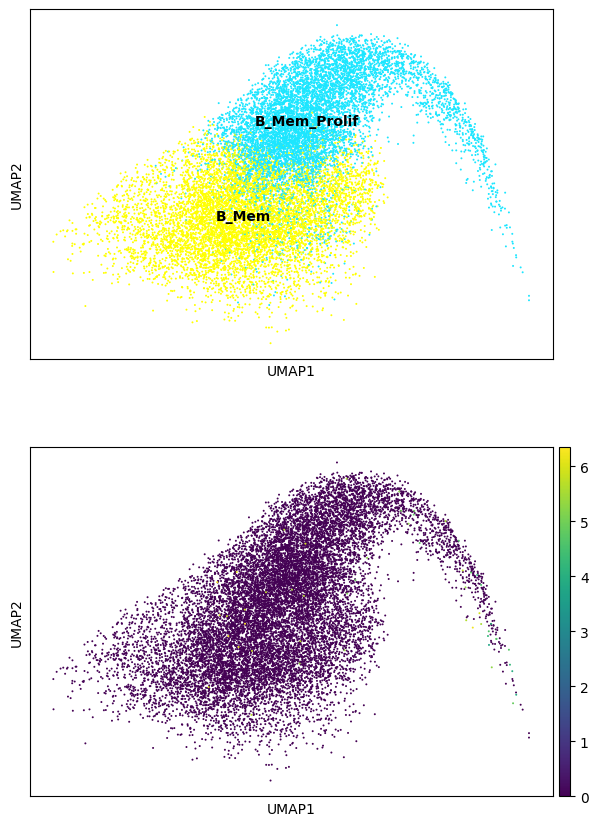

In [20]:
sc.pl.umap(
    adata[adata.obs["ct2"].isin(["B_Mem", "B_Mem_Prolif"])].copy(),
    color=["ct2", "MKI67"],
    ncols=1,
    save="B_Mem_umap.png",
    legend_loc="on data",
    title=["", ""]
)